<a href="https://colab.research.google.com/github/jawahirkhaleel/-jawahirkhaleel-/blob/main/Tu%CC%88rkiye_Elevation_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Erzincan Elevation, Türkiye (2019)

Part of the [InSAR.dev](https://insar.dev) Python ecosystem for SAR and InSAR processing. Free for personal and educational purposes; professional/funded use requires an active [license](https://pechnikov.dev).

### Resources
- Documentation and examples on [Patreon](https://www.patreon.com/pechnikov)
- Source code on [GitHub](https://github.com/InSARdev)
- Docker images on [DockerHub](https://hub.docker.com/r/insardev/)
- Updates on [LinkedIn](https://www.linkedin.com/in/alexey-pechnikov/)
- Tutorials on [YouTube](https://www.youtube.com/@alexeypechnikov)

© InSAR.dev, 2026

$\large\color{blue}{\text{Hint: Use menu Cell} \to \text{Run All or Runtime} \to \text{Complete All or Runtime} \to \text{Run All}}$
$\large\color{blue}{\text{(depending of your localization settings) to execute the entire notebook}}$

# Stage 1 — Pre-processing: Sentinel-1 SLC to a geocoded Zarr stack

`insardev_pygmtsar` downloads the bursts and their orbits, coregisters them against a reference
date and writes a geocoded, chunked Zarr stack.

**Already have the Zarr stack?** Skip to Stage 2; nothing in Stage 1 is needed again.

## Google Colab installation

In [ ]:
import sys, os
if 'google.colab' in sys.modules:
  #!{sys.executable} -m pip install -qq --progress-bar off insardev-toolkit insardev-pygmtsar
  !{sys.executable} -m pip install -qq --progress-bar off \
    "insardev_toolkit  @ git+https://github.com/InSARdev/core@main#subdirectory=insardev_toolkit" \
    "insardev_pygmtsar @ git+https://github.com/InSARdev/core@main#subdirectory=insardev_pygmtsar"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.67.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.


## Import Python modules

In [ ]:
import geopandas as gpd
import json
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# import modules to be used in the notebook
from insardev_pygmtsar import S1
from insardev_toolkit import UI, EOF, ASF, Tiles, XYZTiles
UI('dark')

## Area and bursts

Two descending acquisitions six days apart over Erzincan in eastern Türkiye, three IW2 bursts
each. Six days is short enough that the ground barely changes, so what the interferogram carries
is essentially topography — which is exactly what this notebook turns back into a DEM.

Browse the selection in ASF Vertex:
[2019-07-02](https://search.asf.alaska.edu/#/?dataset=SENTINEL-1%20BURSTS&polygon=LINESTRING(39.5%2040,40%2039.5)&start=2019-07-01T17:00:00Z&end=2019-07-02T16:59:59Z&resultsLoaded=true&granule=S1_262885_IW2_20190702T032452_VV_69C5-BURST&zoom=8.867&center=39.720,39.246&polarizations=VV&flightDirs=Descending) ·
[2019-07-08](https://search.asf.alaska.edu/#/?dataset=SENTINEL-1%20BURSTS&polygon=LINESTRING(39.5%2040,40%2039.5)&start=2019-07-07T17:00:00Z&end=2019-07-09T16:59:59Z&resultsLoaded=true&granule=S1_262886_IW2_20190708T032537_VV_33CA-BURST&zoom=8.867&center=39.720,39.246&polarizations=VV&flightDirs=Descending)

In [ ]:
# Specify bursts to download
BURSTS = """
S1_262887_IW2_20190702T032458_VV_69C5-BURST
S1_262886_IW2_20190702T032455_VV_69C5-BURST
S1_262885_IW2_20190702T032452_VV_69C5-BURST

S1_262887_IW2_20190708T032540_VV_33CA-BURST
S1_262886_IW2_20190708T032537_VV_33CA-BURST
S1_262885_IW2_20190708T032534_VV_33CA-BURST
"""

In [ ]:
geojson = '''
{
  "type": "Feature",
  "geometry": {
    "type": "LineString",
    "coordinates": [[39.5, 40], [40, 39.5]]
  },
  "properties": {}
}
'''
POI = gpd.GeoDataFrame.from_features([json.loads(geojson)])

## Directories

In [ ]:
# directory where Sentinel-1 bursts and orbits will be downloaded
DATADIR = 'data'
# path to the downloaded DEM file
DEM = f'{DATADIR}/dem.nc'
ZARRDIR = 'zarr'

## Download bursts, orbits and DEM

An empty `ASF()` pulls the bursts from the InSAR.dev cache; pass your Earthdata credentials as
`ASF(user, password)` to download from ASF directly. The Copernicus GLO-30 DEM geocodes the
SLCs — and later serves as the independent reference the InSAR elevation is compared against.

In [ ]:
# leave empty to download bursts from InSARDEV global cache (faster) or use your ASF username and password
asf = ASF()
print(asf.download(DATADIR, BURSTS))

NOTE: Using insar.dev Cache API. Free for non-commercial use; license required for funded academic, institutional, or professional use.


                                         burst
0  S1_262887_IW2_20190702T032458_VV_69C5-BURST
1  S1_262886_IW2_20190702T032455_VV_69C5-BURST
2  S1_262885_IW2_20190702T032452_VV_69C5-BURST
3  S1_262887_IW2_20190708T032540_VV_33CA-BURST
4  S1_262886_IW2_20190708T032537_VV_33CA-BURST
5  S1_262885_IW2_20190708T032534_VV_33CA-BURST


In [ ]:
s1 = S1(DATADIR)
s1.to_dataframe().to_file(f"{DATADIR}/s1.geojson", driver="GeoJSON")
s1.to_dataframe()

NOTE: Multiple path numbers found in the dataset: 77, 123.
NOTE: The following reference dates are available: 2019-07-02, 2019-07-08.
NOTE: Loaded 6 bursts.
NOTE: Orbits are not downloaded, baselines are undefined. Download the orbits and scan the data directory again.


startTime  \
fullBurstID    polarization burst                                                                    
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST 2019-07-02 03:24:52.731888   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST 2019-07-08 03:25:34.659293   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST 2019-07-02 03:24:55.492500   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST 2019-07-08 03:25:37.417850   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST 2019-07-02 03:24:58.251057   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST 2019-07-08 03:25:40.178462   

                                                                        flightDirection  \
fullBurstID    polarization burst                                                         
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST      Descending   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST      Descending   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST      Descending   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST      Descending   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST      Descending   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST      Descending   

                                                                         pathNumber  \
fullBurstID    polarization burst                                                     
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST          77   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST         123   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST          77   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST         123   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST          77   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST         123   

                                                                        subswath  \
fullBurstID    polarization burst                                                  
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST      IW2   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST      IW2   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST      IW2   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST      IW2   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST      IW2   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST      IW2   

                                                                        mission  \
fullBurstID    polarization burst                                                 
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST     S1B   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST     S1A   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST     S1B   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST     S1A   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST     S1B   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST     S1A   

                                                                        beamModeType  \
fullBurstID    polarization burst                                                      
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST           IW   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST           IW   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST           IW   
                            S1_262886_IW2_20190708T032537_VV_33CA-BU

In [ ]:
# scan the data directory for Sentinel-1 SLC bursts and download related orbits
EOF().download(DATADIR, s1.to_dataframe())

,orbit
0,S1B_OPER_AUX_POEORB_OPOD_20210330T214422_V2019...
1,S1A_OPER_AUX_POEORB_OPOD_20210330T235242_V2019...


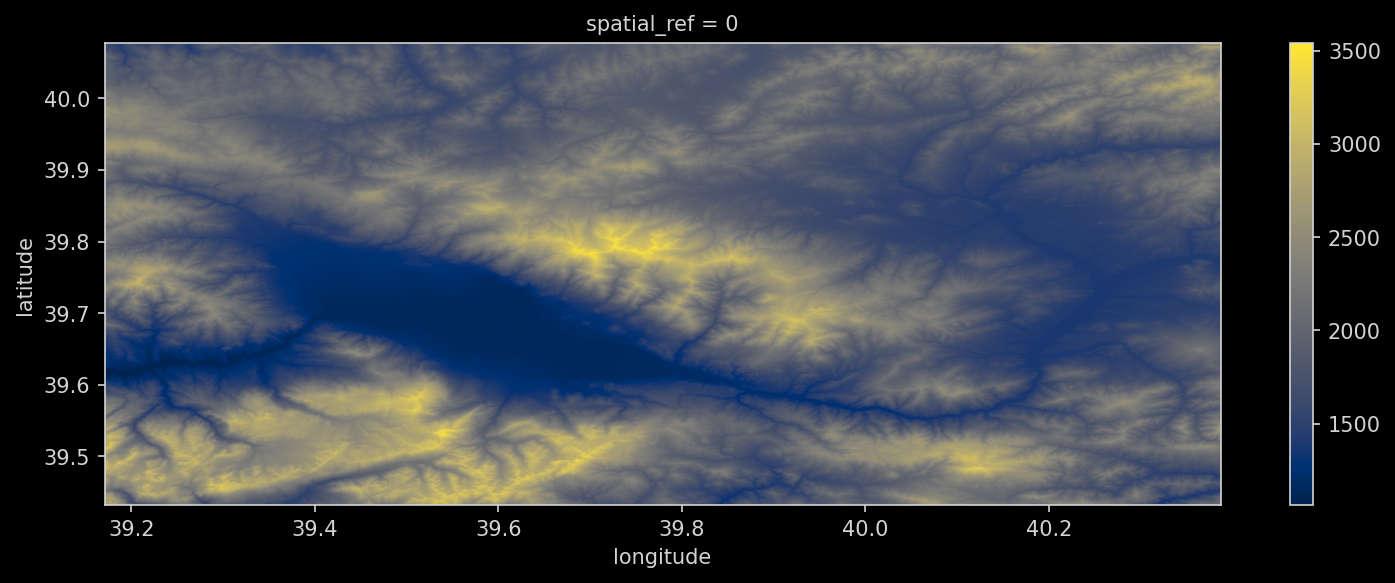

In [ ]:
# download Copernicus Global DEM 1 arc-second
Tiles().download_dem(s1.to_dataframe(), provider='GLO', filename=DEM).plot.imshow(cmap='cividis')

## Coregister and geocode

Two arguments matter for this notebook:

- **`remove_topo_phase=False`** keeps the topographic phase in the data. Every other notebook
  removes it to see deformation; here it *is* the signal.
- **`reference_height=2000`** sets the flat-earth reference the phase is measured against, put
  near the mean terrain height of this scene so the residual fringe rate stays low and the
  interferogram unwraps cleanly.

In [ ]:
# scan SLC bursts with DEM
s1 = S1(DATADIR, DEM=DEM)
s1.to_dataframe()

NOTE: Multiple path numbers found in the dataset: 77, 123.
NOTE: The following reference dates are available: 2019-07-02, 2019-07-08.
NOTE: Loaded 6 bursts.


Computing Baselines      : 100%|██████████| 2/2 [00:00<00:00,  8.06it/s]


NOTE: 123_262885_IW2 baselines are measured from 2019-07-02.


Computing Baselines      : 100%|██████████| 2/2 [00:00<00:00,  9.06it/s]


NOTE: 123_262886_IW2 baselines are measured from 2019-07-02.


Computing Baselines      : 100%|██████████| 2/2 [00:00<00:00,  9.30it/s]

NOTE: 123_262887_IW2 baselines are measured from 2019-07-02.


startTime  \
fullBurstID    polarization burst                                                                    
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST 2019-07-02 03:24:52.731888   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST 2019-07-08 03:25:34.659293   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST 2019-07-02 03:24:55.492500   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST 2019-07-08 03:25:37.417850   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST 2019-07-02 03:24:58.251057   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST 2019-07-08 03:25:40.178462   

                                                                        flightDirection  \
fullBurstID    polarization burst                                                         
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST      Descending   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST      Descending   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST      Descending   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST      Descending   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST      Descending   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST      Descending   

                                                                         pathNumber  \
fullBurstID    polarization burst                                                     
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST          77   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST         123   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST          77   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST         123   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST          77   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST         123   

                                                                        subswath  \
fullBurstID    polarization burst                                                  
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST      IW2   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST      IW2   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST      IW2   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST      IW2   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST      IW2   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST      IW2   

                                                                        mission  \
fullBurstID    polarization burst                                                 
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST     S1B   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST     S1A   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST     S1B   
                            S1_262886_IW2_20190708T032537_VV_33CA-BURST     S1A   
123_262887_IW2 VV           S1_262887_IW2_20190702T032458_VV_69C5-BURST     S1B   
                            S1_262887_IW2_20190708T032540_VV_33CA-BURST     S1A   

                                                                        beamModeType  \
fullBurstID    polarization burst                                                      
123_262885_IW2 VV           S1_262885_IW2_20190702T032452_VV_69C5-BURST           IW   
                            S1_262885_IW2_20190708T032534_VV_33CA-BURST           IW   
123_262886_IW2 VV           S1_262886_IW2_20190702T032455_VV_69C5-BURST           IW   
                            S1_262886_IW2_20190708T032537_VV_33CA-BU

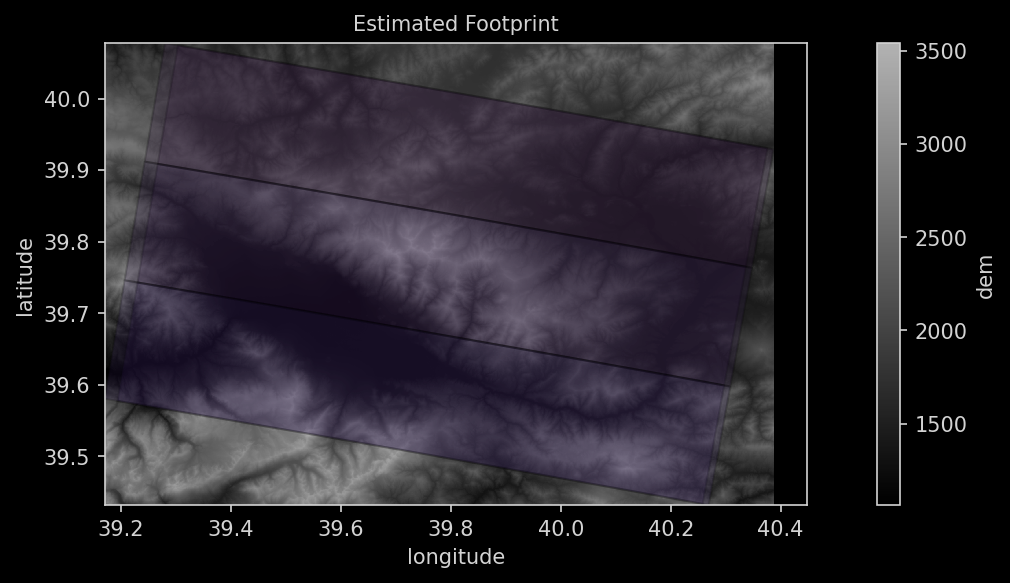

In [ ]:
# preview selected bursts
s1.plot(ref='2019-07-02')

In [ ]:
# load SLC bursts and orbits with DEM and transform to ZARR
s1.transform(ZARRDIR, ref='2019-07-02', reference_height=2000, remove_topo_phase=False)

NOTE: EPSG code is computed automatically for all bursts: 32637.
NOTE: Using 3 workers for 3 bursts, 2 dates each (burst-parallel, scheduler=None).


Transforming SLC...      : 100%|██████████| 3/3 [01:16<00:00, 25.55s/it]


# Stage 2 — Processing: interferogram, unwrapping, elevation

Everything below reads the Zarr stack and needs nothing from Stage 1.

## Load and set up Python modules

In [ ]:
import sys, os
if 'google.colab' in sys.modules:
  #!{sys.executable} -m pip install -qq --progress-bar off insardev insardev-toolkit
  !{sys.executable} -m pip install -qq --progress-bar off \
    "insardev_toolkit  @ git+https://github.com/InSARdev/core@main#subdirectory=insardev_toolkit" \
    "insardev          @ git+https://github.com/InSARdev/core@main#subdirectory=insardev"
  !{sys.executable} -m pip install -qq --progress-bar off  "pyvista<0.49" xvfbwrapper jupyter_bokeh vtk panel
  #trame trame-vuetify trame-vtk
  from google.colab import output
  output.enable_custom_widget_manager()

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# import modules to be used in the notebook
from insardev import Stack
from insardev_toolkit.HTTP import unzip
from insardev_toolkit import UI
UI('dark')

In [ ]:
# 3D plotting modules
import pyvista as pv
pv.set_plot_theme("dark")
from IPython.display import display, HTML
if 'google.colab' in sys.modules:
    import panel
    panel.extension(comms='ipywidgets')
    panel.extension('vtk')

## Directories

In [ ]:
ZARRDIR = 'zarr'

## Download and Unpack Datasets

We can process datasets hosted on GitHub, Zenodo, or other platforms in a single workflow.

In [ ]:
# example downloading command
#unzip("https://zenodo.org/records/15347694/files/Türkiye_Elevation-40x10-004.zip", ZARRDIR)

## Dask cluster

Every step below is lazy — the calls build a task graph and `.compute()` runs it — so a laptop
can process a stack far larger than its memory.

In [ ]:
if 'client' in globals():
    client.shutdown()
    client.close()
import logging
logging.getLogger('distributed').setLevel(logging.CRITICAL)
from dask.distributed import Client
client = Client(silence_logs='CRITICAL', threads_per_worker=2, resources={'gpu': 1})
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 12,Total memory: 52.96 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42881,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36697,Total threads: 2
Dashboard: http://127.0.0.1:41063/status,Memory: 8.83 GiB
Nanny: tcp://127.0.0.1:46033,


## Load the stack

`align()` puts the bursts of both dates on a common grid.

In [ ]:
stack = Stack().load(ZARRDIR).align()
stack

Loading Dataset...       : 100%|██████████| 3/3 [00:03<00:00,  1.24s/it]


Stack containing 3 items for 2 date (123_262885_IW2 … 123_262887_IW2)

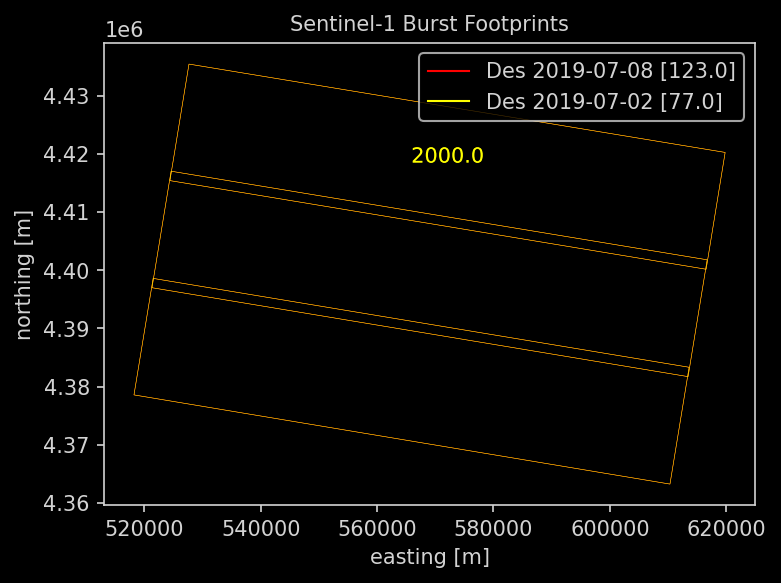

In [ ]:
stack.plot(cmap='autumn', alpha=0.15)

## Interferogram

The cell below writes out the definition rather than calling the `interferogram()` one-liner, so
each term is visible:

- `ref * rep.conj()` is the complex phase difference of the two acquisitions;
- `gaussian(wavelength=100)` is the anti-aliasing filter — and the spatial averaging that makes
  a correlation estimate possible at all, since coherence is undefined for a single look;
- correlation is that averaged product normalised by the two averaged intensities;
- `goldstein(corr, 32)` sharpens the fringes adaptively, using the correlation as the weight;
- `angle()` takes the wrapped phase and `downsample(40)` moves it to a 40 m grid.

The commented one-liner at the top produces the same result.

In [ ]:
# this one-liner is a common way to calculate interferogram and correlation
#intf, corr = stack.pairs([1,0]).interferogram(wavelength=100).goldstein(32).angle().downsample(40).compute()
# alternatively, we can write the full definition of interferometry phase and correlation
ref, rep = stack.pairs([1,0])
# Gaussian filtering required for correlation estimation
phase_diff = (ref * rep.conj()).gaussian(100)
intensity_ref = ref.power().gaussian(100)
intensity_rep = rep.power().gaussian(100)
corr = (phase_diff.abs() / (intensity_ref * intensity_rep).sqrt()).clip(0, 1)
# use correlation for adaptive Goldstein filtering
intf = phase_diff.goldstein(corr, 200).angle().downsample(40).compute()
# both ways produce the same interferogram
intf

Computing Batch...       : 100%|██████████| 563/563 [00:12<00:00, 45.32it/s]


BatchWrap containing 3 items for 1 pair (123_262885_IW2 … 123_262887_IW2)

In [ ]:
# unify bursts and downsample to 40m, anti-aliasing Gaussian filter 100m is already applied above
intf = intf.dissolve().compute()

Computing Batch...       : 100%|██████████| 607/607 [00:00<00:00, 752.09it/s] 


Computing VV Plot        : 100%|██████████| 615/615 [00:00<00:00, 3051.78it/s]


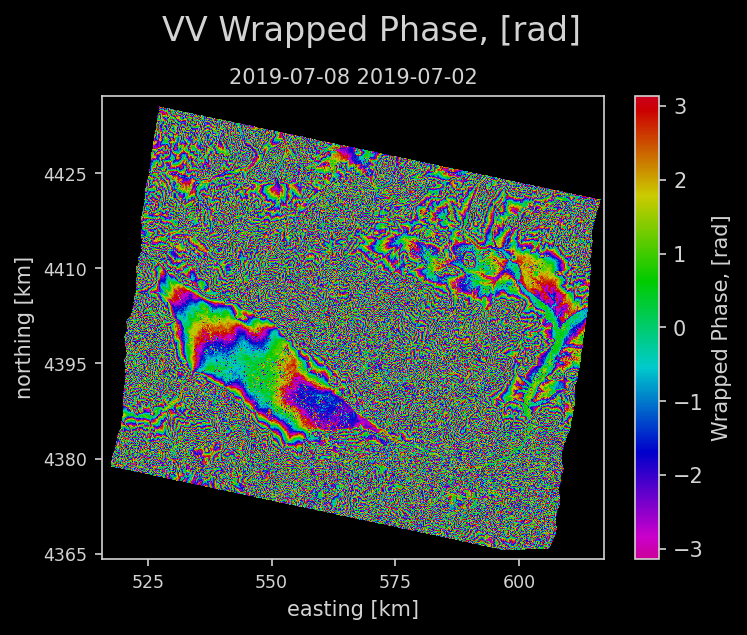

In [ ]:
intf.plot(alpha=0.8, caption='Wrapped Phase, [rad]');

### Interferogram draped on the DEM

In [ ]:
intf.downsample(100).to_vtk('vtk', stack.transform())

Exporting VTK: 100%|██████████| 1/1 [00:00<00:00,  2.53it/s]


In [ ]:
# build interactive 3D plot
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(pv.read('vtk/VV.vtk').scale([1, 1, 4], inplace=True), scalars='20190708_20190702', cmap='turbo', ambient=0.1, show_scalar_bar=True)
plotter.show_axes()
plot = plotter.show(screenshot='3D Interferogram.png', jupyter_backend='panel' if 'google.colab' in sys.modules else 'client', return_viewer=True)
if 'google.colab' in sys.modules:
    plot = panel.panel(
        plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
        enable_keybindings=False, sizing_mode='stretch_width', min_height=600
    )
display(HTML('<h1 style="text-align:center; margin-bottom:0;">Interactive Sentinel-1 Interferogram on DEM</h1>'))
plot

## Unwrapping

The fringes have to be counted before they mean a height. With topography as the only signal and
a six-day pair, the phase is smooth and unwraps in one pass; `dissolve()` then merges the three
bursts into one continuous raster.

In [ ]:
phase = intf.unwrap2d().compute()
phase

Computing Batch...       :  88%|████████▉ | 607/683 [00:00<00:00, 52552.17it/s]


Batch containing 3 items for 1 pair (123_262885_IW2 … 123_262887_IW2)

In [ ]:
# unify bursts
phase = phase.align().dissolve()

Computing VV Plot        : 100%|██████████| 671/671 [00:13<00:00, 51.22it/s]  


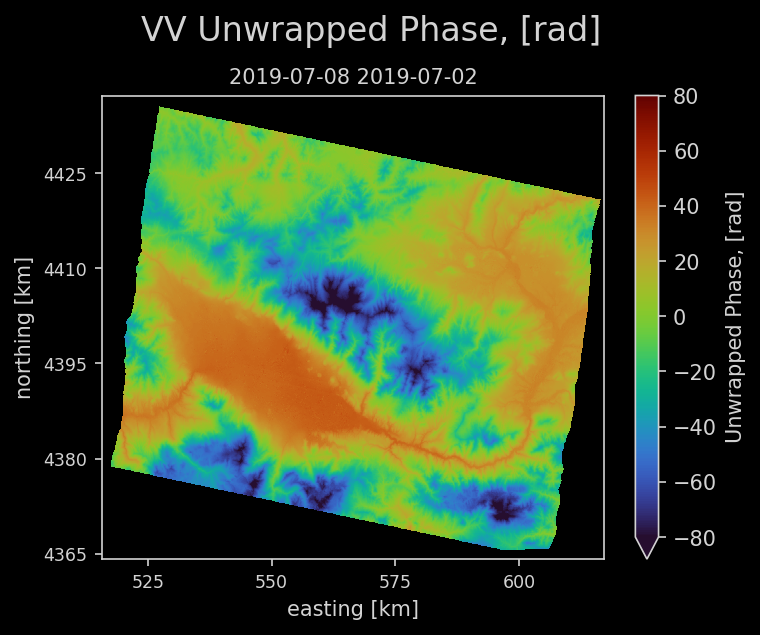

In [ ]:
phase.plot(vmin=-80, vmax=80, alpha=0.8, caption='Unwrapped Phase, [rad]');

In [ ]:
phase.downsample(100).to_vtk('phase', stack.transform())

Exporting VTK: 100%|██████████| 1/1 [00:00<00:00,  2.53it/s]


In [ ]:
# build interactive 3D plot
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(pv.read('phase/VV.vtk').scale([1, 1, 4], inplace=True), scalars='20190708_20190702', cmap='turbo', ambient=0.1, show_scalar_bar=True)
plotter.show_axes()
plot = plotter.show(screenshot='3D Phase.png', jupyter_backend='panel' if 'google.colab' in sys.modules else 'client', return_viewer=True)
if 'google.colab' in sys.modules:
    plot = panel.panel(
        plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
        enable_keybindings=False, sizing_mode='stretch_width', min_height=600
    )
display(HTML('<h1 style="text-align:center; margin-bottom:0;">Interactive Sentinel-1 Phase on DEM</h1>'))
plot

## From phase to elevation

How much height one fringe is worth depends on the perpendicular baseline: the larger it is, the
more sensitive the pair is to topography and the more fringes a given hill produces. That number
— the *height of ambiguity* — is what the next cell prints, and it sets both the sensitivity and
the unwrapping difficulty of the pair.

In [ ]:
# for reference, compute height for a single fringe
import numpy as np
baseline = intf.isel(0).data.BPR.round(3).item(0)
print ('baseline =', baseline)
height = stack.elevation(2*np.pi, baseline)
print('height for a single fringe =', height, 'meters')

baseline = 158.855
height for a single fringe = 1902.435 meters


In [ ]:
elevation = phase.elevation(stack.transform())
elevation

Batch containing 3 items for 1 pair (123_262885_IW2 … 123_262887_IW2)

### Compare against the Copernicus GLO-30 DEM

The DEM took no part in producing this elevation — the topographic phase was never removed — so
it is an independent reference. Both fields are mean-subtracted first, because a single
interferogram fixes shape, not absolute height: the unwrapped phase carries an unknown constant.

In [ ]:
# select one burst for the original area
ele = elevation.isel(1).data.VV[0]
topo = stack.transform().isel(1).data.ele.interp_like(ele)

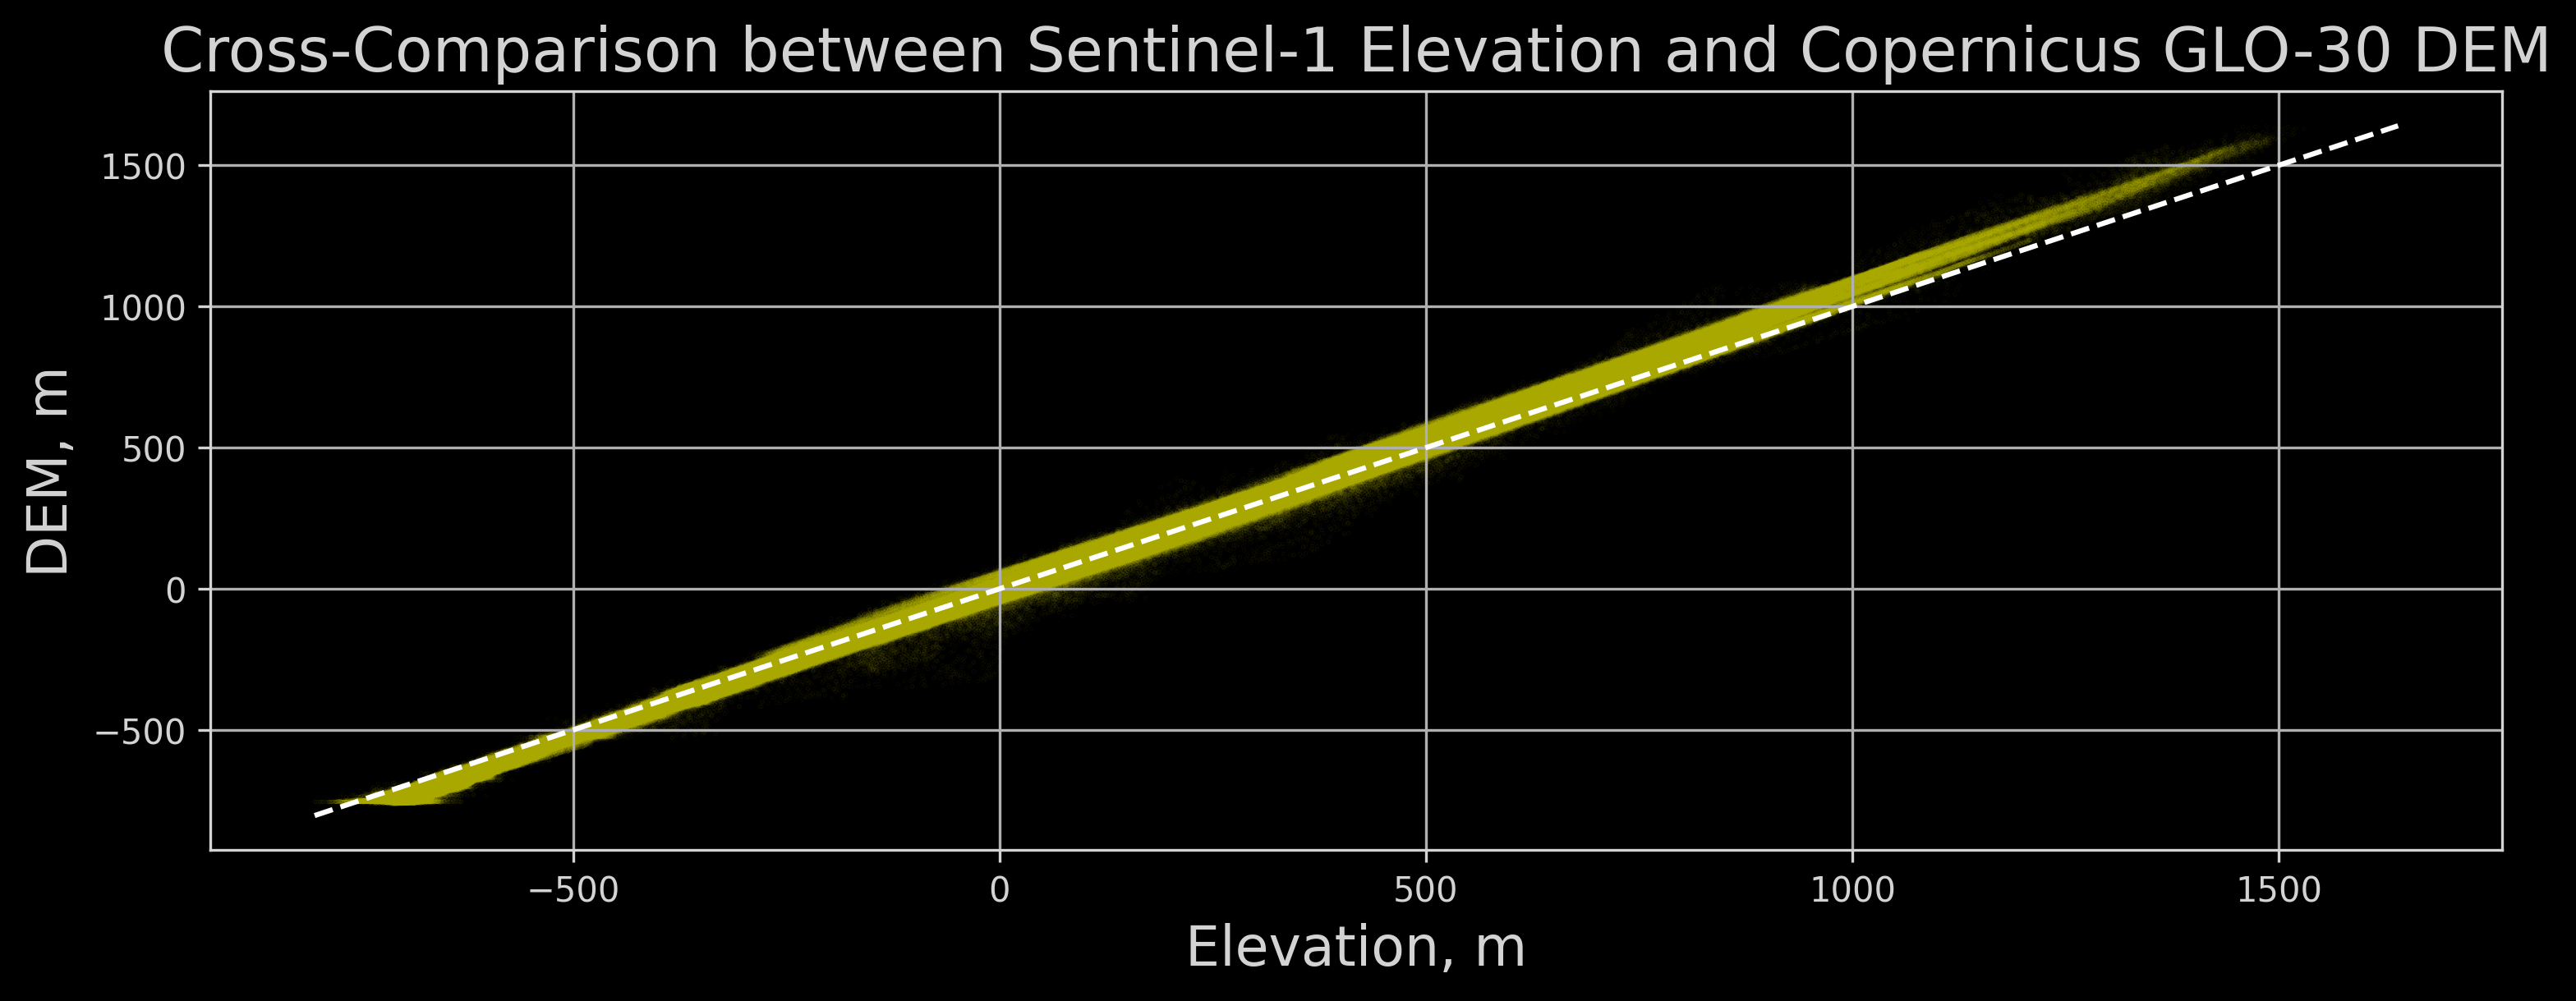

In [ ]:
points_topo = topo.values.ravel()
points_ele = ele.values.ravel()
nanmask = np.isnan(points_topo) | np.isnan(points_ele)
points_topo = points_topo[~nanmask]
points_ele = points_ele[~nanmask]

points_topo = points_topo - points_topo.mean()
points_ele = points_ele - points_ele.mean()

plt.figure(figsize=(12, 4), dpi=300)
plt.scatter(points_ele, points_topo, c='y', alpha=0.1, s=0.01)

# adding a 1:1 line
max_value = max(points_topo.max(), points_ele.max())
min_value = min(points_topo.min(), points_ele.min())
plt.plot([min_value, max_value], [min_value, max_value], 'w--')

plt.xlabel('Elevation, m', fontsize=16)
plt.ylabel('DEM, m', fontsize=16)
plt.title('Cross-Comparison between Sentinel-1 Elevation and Copernicus GLO-30 DEM', fontsize=18)
plt.grid(True)
plt.show()

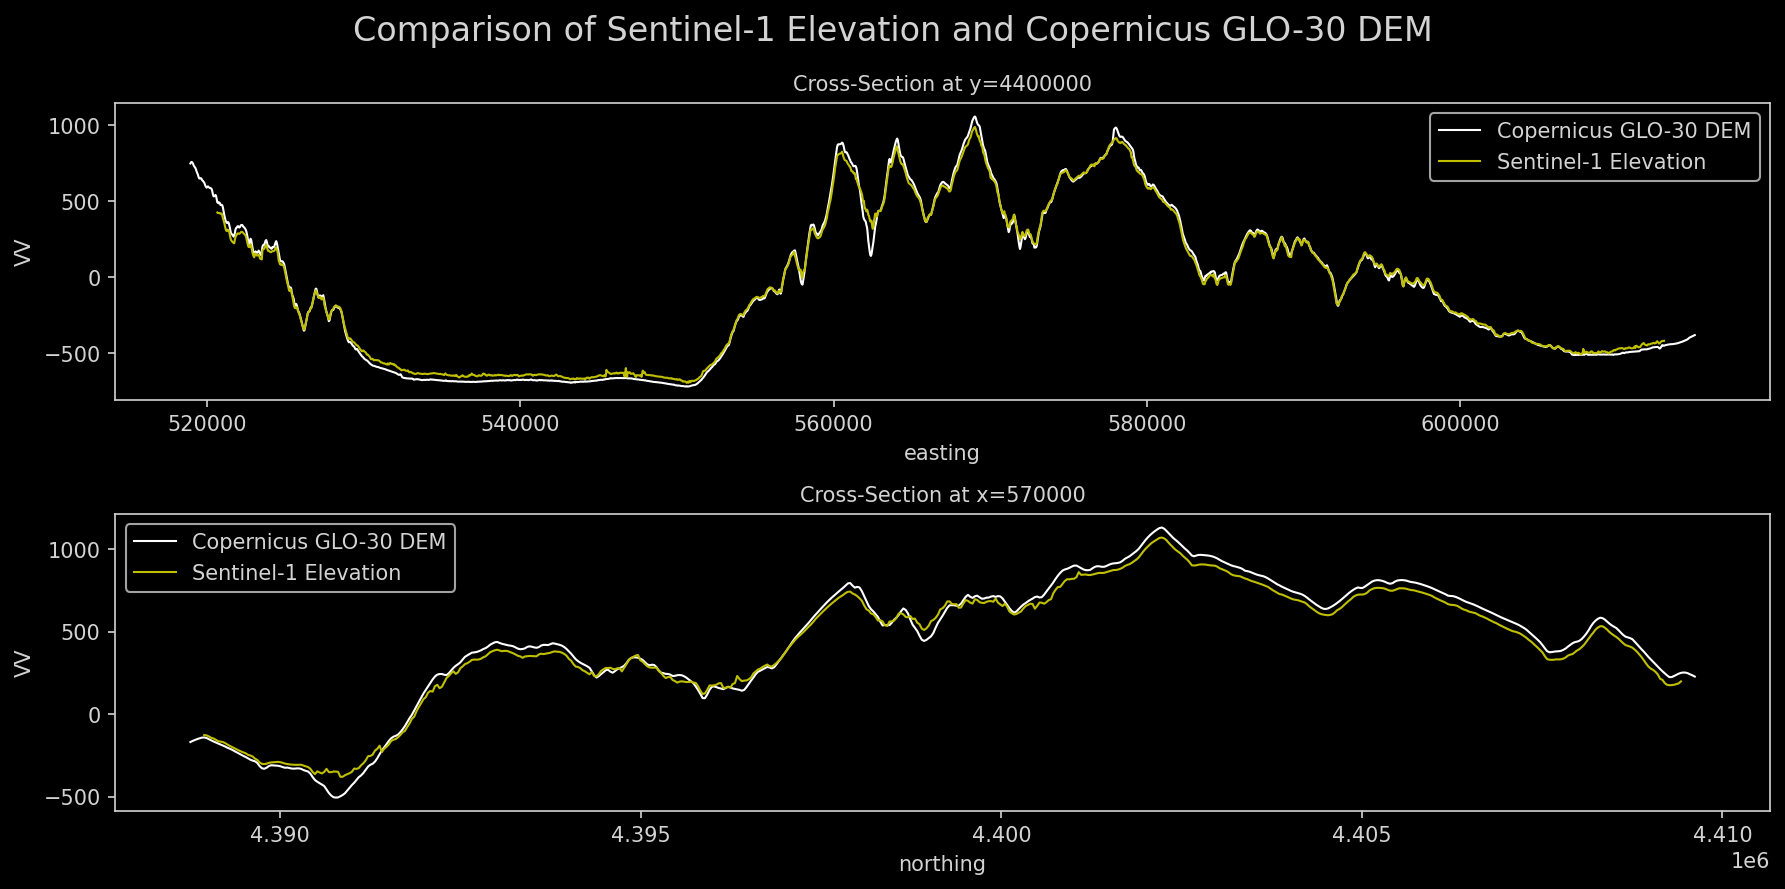

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

topo_y = (topo - topo.mean()).sel(y=4400000, method='nearest')
ele_y = (ele - ele.mean()).sel(y=4400000, method='nearest')
topo_y.plot(ax=axes[0], color='w', ls='-', lw=1, label='Copernicus GLO-30 DEM')
ele_y.plot(ax=axes[0], color='y', ls='-', lw=1, label='Sentinel-1 Elevation')
axes[0].set_title('Cross-Section at y=4400000')
axes[0].legend()

topo_x = (topo - topo.mean()).sel(x=570000, method='nearest')
ele_x = (ele - ele.mean()).sel(x=570000, method='nearest')
topo_x.plot(ax=axes[1], color='w', ls='-', lw=1, label='Copernicus GLO-30 DEM')
ele_x.plot(ax=axes[1], color='y', ls='-', lw=1, label='Sentinel-1 Elevation')
axes[1].set_title('Cross-Section at x=570000')
axes[1].legend()

plt.suptitle('Comparison of Sentinel-1 Elevation and Copernicus GLO-30 DEM')
plt.tight_layout()
plt.show()

### Side by side in 3D

In [ ]:
elevation.downsample(100).to_vtk('elevation', stack.transform())
stack.transform()[['ele']].downsample(100).to_vtk('topo', stack.transform())

Exporting VTK: 100%|██████████| 1/1 [00:00<00:00,  4.47it/s]


In [ ]:
# build interactive 3D plot
plotter = pv.Plotter(shape=(1, 2), notebook=True)
plotter.subplot(0, 0)
plotter.add_mesh(pv.read('elevation/VV.vtk').scale([1, 1, 4], inplace=True), scalars='20190708_20190702', cmap='turbo', ambient=0.1, show_scalar_bar=True)
plotter.subplot(0, 1)
plotter.add_mesh(pv.read('topo/ele.vtk').scale([1, 1, 4], inplace=True), scalars='ele', cmap='turbo', ambient=0.1, show_scalar_bar=True)
plotter.show_axes()
plot = plotter.show(screenshot='3D Elevation.png', jupyter_backend='panel' if 'google.colab' in sys.modules else 'client', return_viewer=True)
if 'google.colab' in sys.modules:
    plot = panel.panel(
        plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
        enable_keybindings=False, sizing_mode='stretch_width', min_height=600
    )
display(HTML('<h1 style="text-align:center; margin-bottom:0;">Interactive Sentinel-1 Elevation vs GLO-30 DEM</h1>'))
plot

## Save the Results

Save the results in geospatial data formats like to NetCDF, GeoTIFF and others. The both formats (NetCDF and GeoTIFF) can be opened in QGIS and other GIS applications.

In [ ]:
elevation.to_dataset().VV[0].rio.to_raster('elevation.tif')
#elevation.align().to_dataset().ele[0].to_netcdf('elevation.nc')

## Export from Google Colab

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download('elevation/VV.vtk')
    #files.download('elevation.nc')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>